<a href="https://colab.research.google.com/github/Deeksha123-06/Gold-price-prediction/blob/main/gold%20price%20prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
pip install xgboost

In [2]:
import pandas as pd
import numpy as np
from sklearn.model_selection import TimeSeriesSplit,GridSearchCV
from sklearn.metrics import mean_absolute_error,r2_score
from xgboost import XGBRegressor
import matplotlib.pyplot as plt

In [3]:
df = pd.read_csv('/content/gld_price_data.csv')

In [4]:
df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values('Date')


In [5]:
df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month


In [6]:
df['GLD_lag1'] = df['GLD'].shift(1)
df['GLD_lag2'] = df['GLD'].shift(2)

In [7]:
df = df.dropna()

In [8]:
df = df.drop(['Date'], axis=1)

In [9]:
X = df.drop('GLD', axis=1)
y = df['GLD']

In [10]:
split_index = int(len(df) * 0.8)

X_train, X_test = X[:split_index], X[split_index:]
y_train, y_test = y[:split_index], y[split_index:]

In [11]:
model = XGBRegressor(random_state=42)

param_grid = {
    'n_estimators': [200, 300],
    'max_depth': [4, 5, 6],
    'learning_rate': [0.03, 0.05],
    'subsample': [0.8],
    'colsample_bytree': [0.8]
}

In [14]:
tscv = TimeSeriesSplit(n_splits=5)

grid_search = GridSearchCV(
    model,
    param_grid,
    cv=tscv,
    scoring='neg_mean_absolute_error',
    n_jobs=-1
)

grid_search.fit(X_train, y_train)
best_model = grid_search.best_estimator_

print("Best Parameters:", grid_search.best_params_)


Best Parameters: {'colsample_bytree': 0.8, 'learning_rate': 0.05, 'max_depth': 4, 'n_estimators': 200, 'subsample': 0.8}


In [15]:
y_pred = best_model.predict(X_test)

In [16]:
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(" Final Model Performance")
print("MAE:", mae)
print("R2 Score:", r2)


 Final Model Performance
MAE: 1.331513587561195
R2 Score: 0.8870069310141506


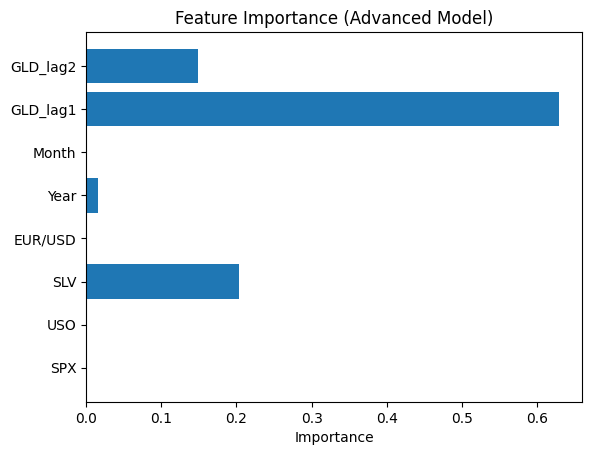

In [17]:
importances = best_model.feature_importances_
features = X.columns

plt.figure()
plt.barh(features, importances)
plt.title("Feature Importance (Advanced Model)")
plt.xlabel("Importance")
plt.show()


In [18]:
new_data = np.array([[1500, 80, 18, 1.3, 2024, 6, 180, 179]])
predicted_price = best_model.predict(new_data)

print("Predicted Gold Price:", predicted_price[0])

Predicted Gold Price: 153.03859
